In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/aqi_india_38cols_knn_final.csv')

In [2]:
df.head()

,city,state,latitude,longitude,datetime,month,day_name,is_weekend,season,time_of_day,...,no2_ugm3,so2_ugm3,o3_ugm3,dust_ugm3,aod,us_aqi,aqi_category,pm25_category_india,festival_period,crop_burning_season
0,agartala,tripura,23.8315,91.2868,2022-08-05 00:00:00,8.0,friday,False,monsoon,night,...,21.8,2.7,32.0,0.0,0.14,289.0,Very Unhealthy,good,False,False
1,agartala,tripura,23.8315,91.2868,2022-08-05 01:00:00,8.0,friday,False,monsoon,night,...,18.5,3.0,33.0,0.0,0.14,289.0,Very Unhealthy,good,False,False
2,agartala,tripura,23.8315,91.2868,2022-08-05 02:00:00,8.0,friday,False,monsoon,night,...,15.1,3.3,34.0,0.0,0.15,54.0,Moderate,good,False,False
3,agartala,tripura,23.8315,91.2868,2022-08-05 03:00:00,8.0,friday,False,monsoon,night,...,14.1,3.3,32.0,0.0,0.15,54.0,Moderate,good,False,False
4,agartala,tripura,23.8315,91.2868,2022-08-05 04:00:00,8.0,friday,False,monsoon,night,...,13.9,3.2,30.0,0.0,0.14,54.0,Moderate,good,False,False


In [3]:
df['aqi_category'].value_counts()

,count
aqi_category,
Moderate,385833
Unhealthy for Sensitive Groups,175125
Good,136476
Unhealthy,130360
Very Unhealthy,14366


In [4]:
df.shape

(842160, 31)

In [ ]:
df.columns

Index(['city', 'state', 'latitude', 'longitude', 'datetime', 'month',
       'day_name', 'is_weekend', 'season', 'time_of_day', 'humidity_percent',
       'dew_point_c', 'wind_gusts_kmh', 'precipitation_mm', 'is_raining',
       'heavy_rain', 'pressure_msl_hpa', 'cloud_cover_percent', 'pm2_5_ugm3',
       'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'dust_ugm3',
       'aod', 'us_aqi', 'aqi_category', 'pm25_category_india',
       'festival_period', 'crop_burning_season'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842160 entries, 0 to 842159
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   city                 842160 non-null  object 
 1   state                842160 non-null  object 
 2   latitude             842160 non-null  float64
 3   longitude            842160 non-null  float64
 4   datetime             842160 non-null  object 
 5   month                842160 non-null  float64
 6   day_name             842160 non-null  object 
 7   is_weekend           842160 non-null  bool   
 8   season               842160 non-null  object 
 9   time_of_day          842160 non-null  object 
 10  humidity_percent     842160 non-null  float64
 11  dew_point_c          842160 non-null  float64
 12  wind_gusts_kmh       842160 non-null  float64
 13  precipitation_mm     842160 non-null  float64
 14  is_raining           842160 non-null  bool   
 15  heavy_rain       

In [6]:
df.describe()

,latitude,longitude,month,humidity_percent,dew_point_c,wind_gusts_kmh,precipitation_mm,pressure_msl_hpa,cloud_cover_percent,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3,dust_ugm3,aod,us_aqi
count,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.00000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000
mean,23.129041,82.769207,6.801653,71.324796,17.160777,19.270394,0.197799,1009.489776,50.50123,34.549825,54.014723,444.932728,15.991785,13.390032,80.188893,19.856400,0.463936,94.712182
std,5.543478,6.937205,3.411504,21.362100,7.020427,9.921461,0.915802,5.698795,43.41348,29.652013,54.231554,377.007222,19.896299,18.921014,44.762719,72.359802,0.299889,47.234756
min,8.524100,72.571400,1.000000,3.000000,-11.500000,3.200000,0.000000,979.400000,0.00000,1.900000,2.300000,96.000000,0.000000,0.200000,0.000000,0.000000,0.050000,19.000000
25%,20.296100,77.173400,4.000000,58.000000,12.100000,11.500000,0.000000,1005.400000,2.00000,14.700000,21.500000,235.000000,3.700000,2.800000,47.000000,0.000000,0.240000,59.000000
50%,23.831500,80.946200,7.000000,76.000000,18.600000,17.300000,0.000000,1009.900000,47.00000,25.900000,39.000000,333.000000,9.000000,6.900000,73.000000,2.000000,0.400000,84.000000
75%,26.912400,88.606500,10.000000,89.000000,23.300000,25.200000,0.000000,1013.800000,100.00000,44.200000,66.400000,508.000000,19.900000,15.800000,108.000000,11.000000,0.610000,128.000000
max,31.104800,94.108600,12.000000,100.000000,27.300000,55.100000,51.700000,1028.100000,100.00000,183.500000,420.000000,2903.000000,122.100000,134.200000,228.000000,714.000000,1.700000,289.000000


In [7]:
df.isnull().sum()

,0
city,0
state,0
latitude,0
longitude,0
datetime,0
month,0
day_name,0
is_weekend,0
season,0
time_of_day,0


In [8]:
df = df.dropna()

In [9]:
df.isnull().sum()

,0
city,0
state,0
latitude,0
longitude,0
datetime,0
month,0
day_name,0
is_weekend,0
season,0
time_of_day,0


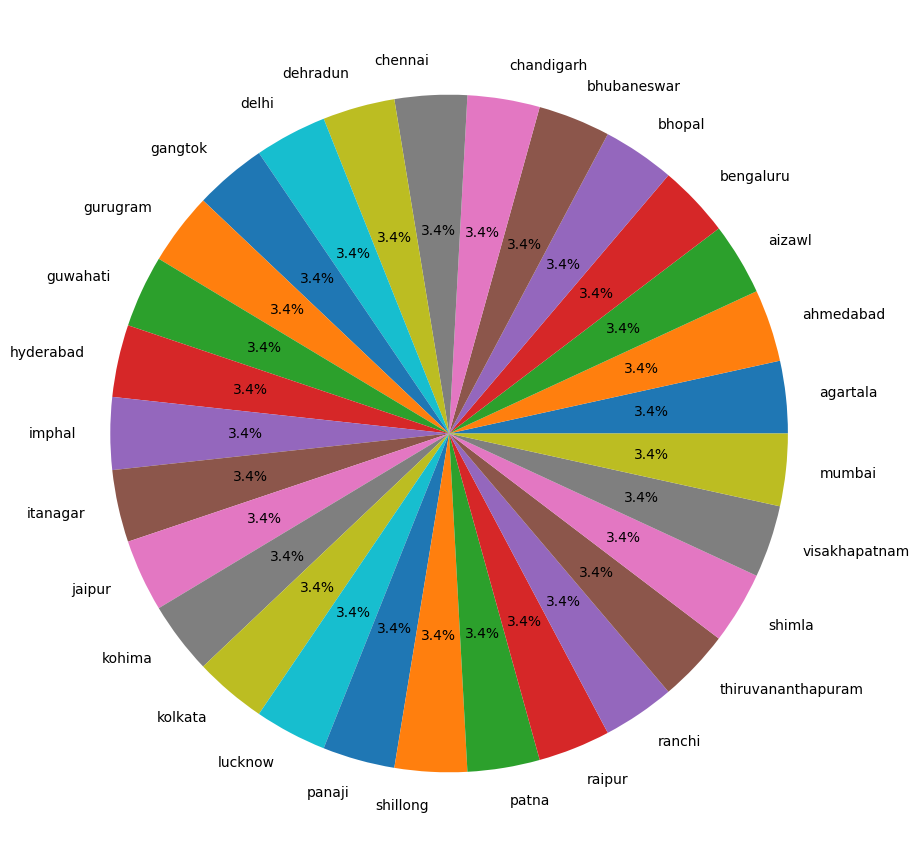

In [10]:
x = df['city'].value_counts()

plt.figure(figsize=(12,11))
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')

plt.show()

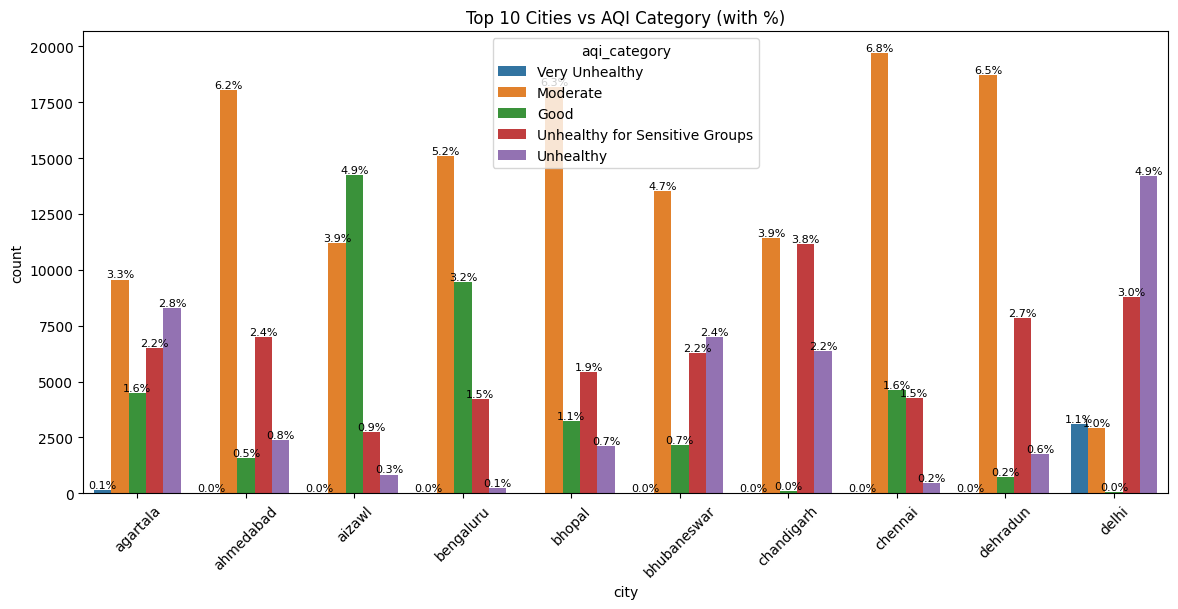

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

top_cities = df['city'].value_counts().head(10).index
df_top = df[df['city'].isin(top_cities)]

plt.figure(figsize=(14,6))
ax = sns.countplot(x='city', hue='aqi_category', data=df_top)

# percentage add
total = len(df_top)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    if percentage > 0:
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45)
plt.title('Top 10 Cities vs AQI Category (with %)')
plt.show()


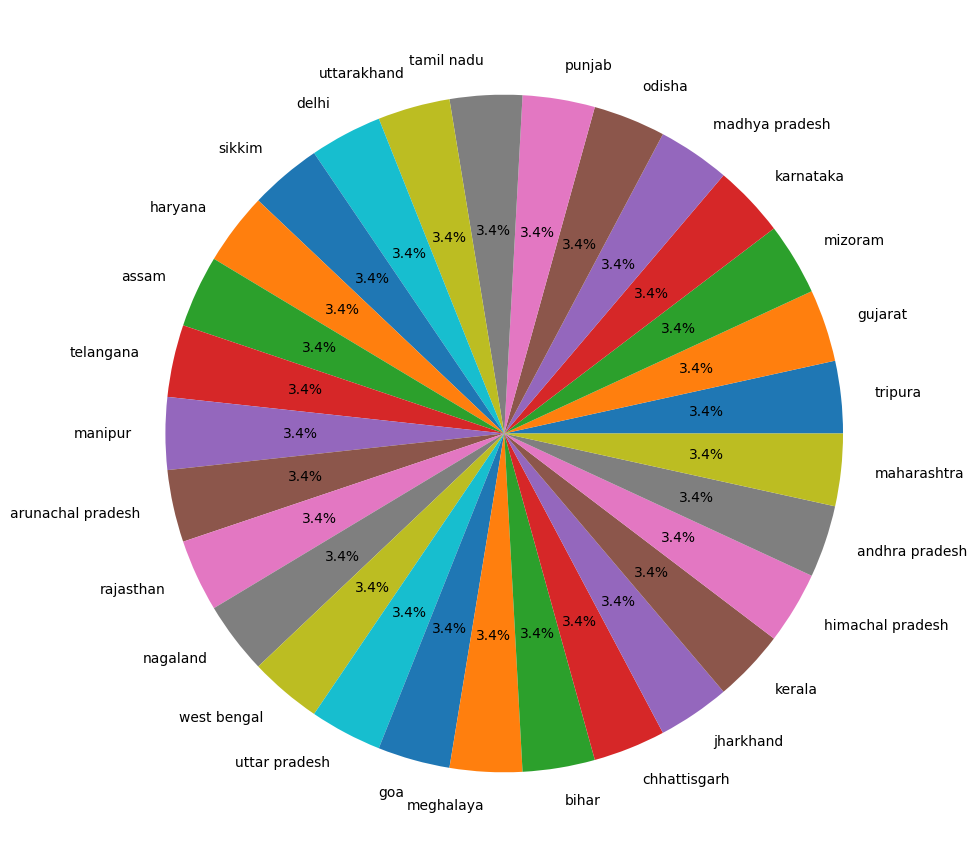

In [12]:
x = df['state'].value_counts()

plt.figure(figsize=(12,11))
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')

plt.show()

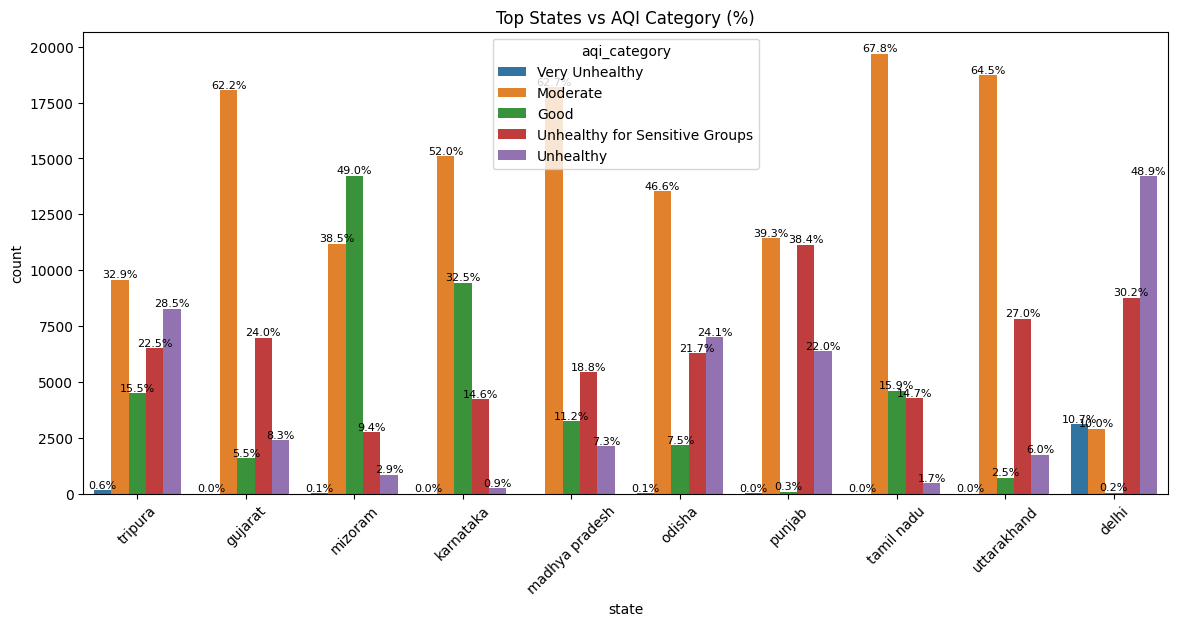

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# top 10 states
top_states = df['state'].value_counts().head(10).index
df_state = df[df['state'].isin(top_states)]

plt.figure(figsize=(14,6))
ax = sns.countplot(x='state', hue='aqi_category', data=df_state)

# state-wise percentage
state_totals = df_state['state'].value_counts()

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue

    state = ax.get_xticklabels()[int(p.get_x() + p.get_width()/2)].get_text()
    total = state_totals[state]

    percent = 100 * height / total

    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45)
plt.title('Top States vs AQI Category (%)')
plt.show()


In [14]:
df["datetime"].value_counts(normalize=True) * 100

,proportion
datetime,
2025-11-26 07:00:00,0.003444
2025-11-26 06:00:00,0.003444
2025-11-26 05:00:00,0.003444
2025-11-26 04:00:00,0.003444
2025-11-26 03:00:00,0.003444
...,...
2022-08-05 02:00:00,0.003444
2022-08-05 01:00:00,0.003444
2022-08-05 00:00:00,0.003444


In [15]:
# sns.countplot(df['datetime'])

datetime column is not directly analyzed because it contains too many unique timestamps. Instead, meaningful temporal features such as month, day_name, season, and time_of_day are extracted and used for analysis.

In [16]:
df["day_name"].value_counts(normalize=True) * 100

,proportion
day_name,
friday,14.297555
saturday,14.297555
sunday,14.297555
tuesday,14.297555
wednesday,14.297555
monday,14.297317
thursday,14.214910


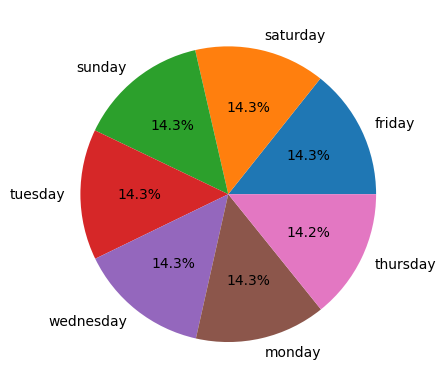

In [17]:
x = df['day_name'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

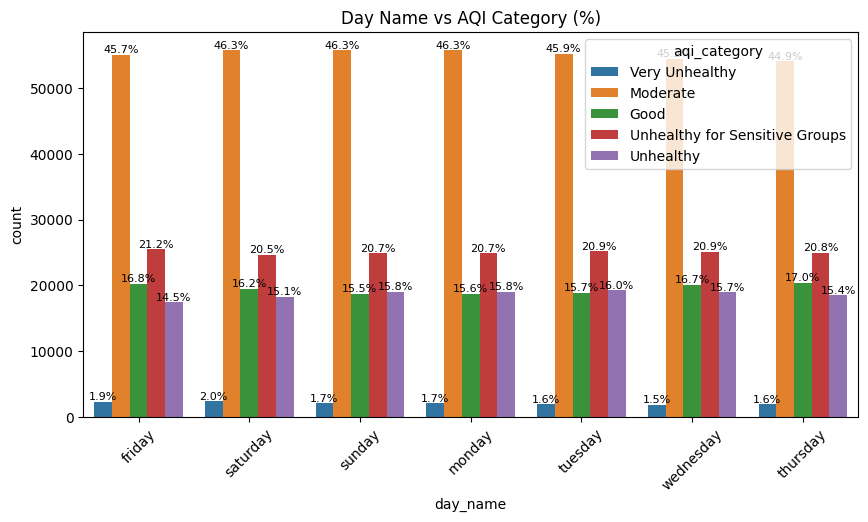

In [18]:
plt.figure(figsize=(10,5))

ax = sns.countplot(x='day_name', hue='aqi_category', data=df)

# day-wise total
day_totals = df['day_name'].value_counts()

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue

    day = ax.get_xticklabels()[int(p.get_x() + p.get_width()/2)].get_text()
    total = day_totals[day]

    percent = 100 * height / total

    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=8)

plt.title('Day Name vs AQI Category (%)')
plt.xticks(rotation=45)
plt.show()


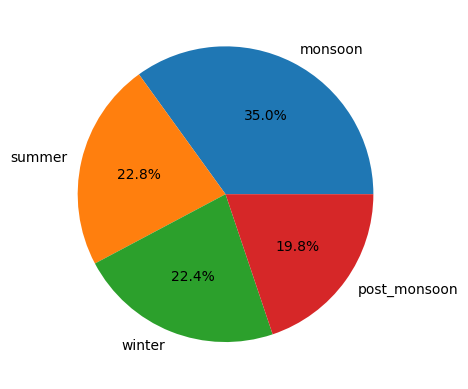

In [19]:
x = df['season'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

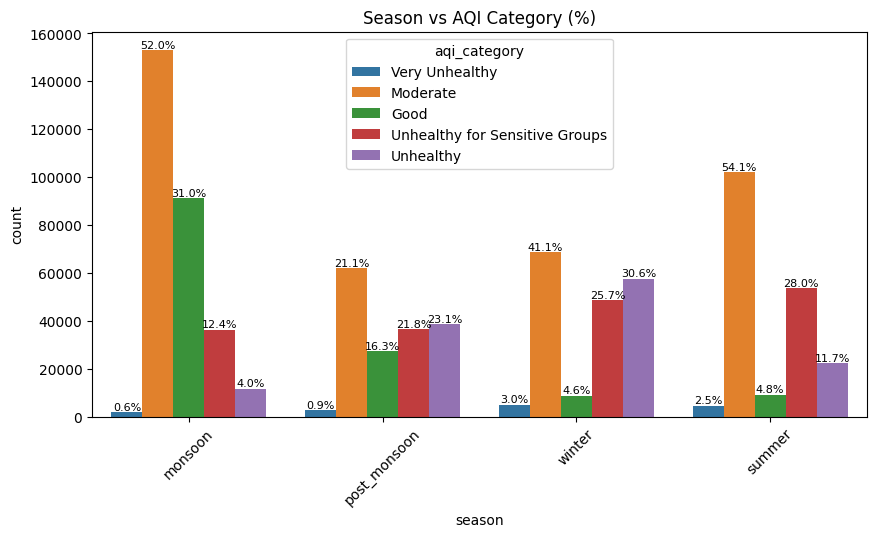

In [20]:
plt.figure(figsize=(10,5))

ax = sns.countplot(x='season', hue='aqi_category', data=df)

season_totals = df['season'].value_counts()

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue

    season = ax.get_xticklabels()[int(p.get_x() + p.get_width()/2)].get_text()
    total = season_totals[season]

    percent = 100 * height / total

    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=8)

plt.title('Season vs AQI Category (%)')
plt.xticks(rotation=45)
plt.show()


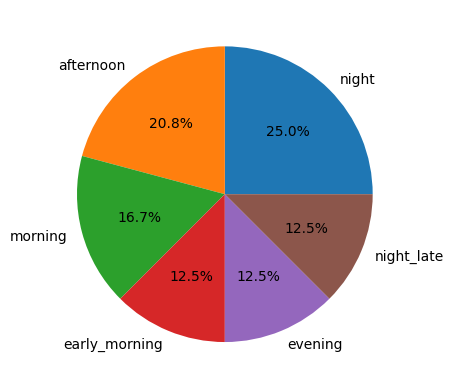

In [21]:
x = df['time_of_day'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

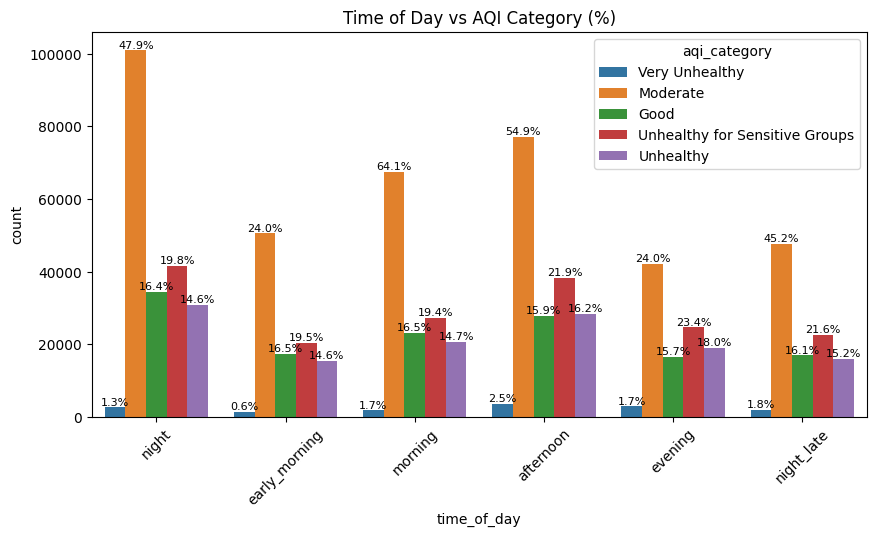

In [22]:
plt.figure(figsize=(10,5))

ax = sns.countplot(x='time_of_day', hue='aqi_category', data=df)

tod_totals = df['time_of_day'].value_counts()

for p in ax.patches:
    h = p.get_height()
    if h == 0:
        continue

    tod = ax.get_xticklabels()[int(p.get_x() + p.get_width()/2)].get_text()
    percent = 100 * h / tod_totals[tod]

    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom', fontsize=8)

plt.title('Time of Day vs AQI Category (%)')
plt.xticks(rotation=45)
plt.show()


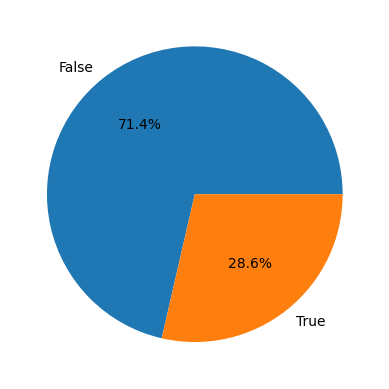

In [23]:
x = df['is_weekend'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

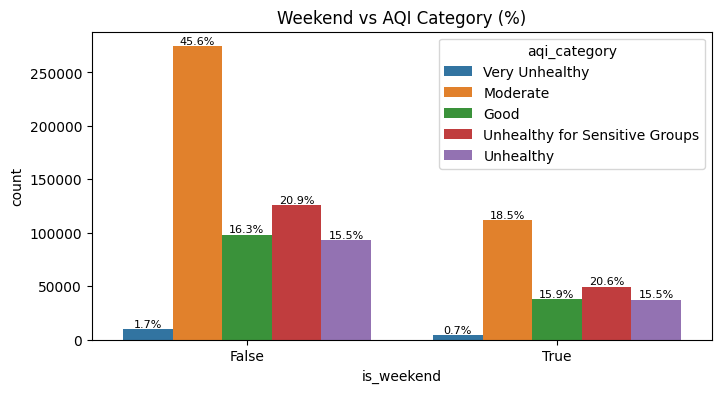

In [24]:
plt.figure(figsize=(8,4))

ax = sns.countplot(x=df['is_weekend'].astype(str), hue='aqi_category', data=df)

wk_totals = df['is_weekend'].astype(str).value_counts()

for p in ax.patches:
    h = p.get_height()
    if h == 0:
        continue
    wk = ax.get_xticklabels()[int(p.get_x() + p.get_width()/2)].get_text()
    if wk in wk_totals:
        percent = 100 * h / wk_totals[wk]
        ax.annotate(f'{percent:.1f}%',
                    (p.get_x() + p.get_width()/2, h),
                    ha='center', va='bottom', fontsize=8)

plt.title('Weekend vs AQI Category (%)')
plt.show()

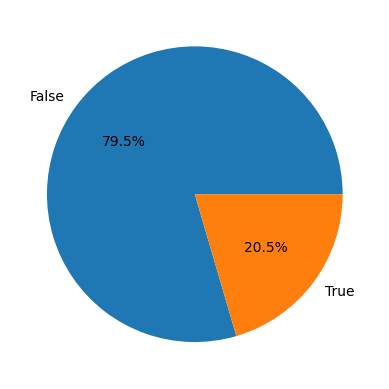

In [25]:
x = df['is_raining'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

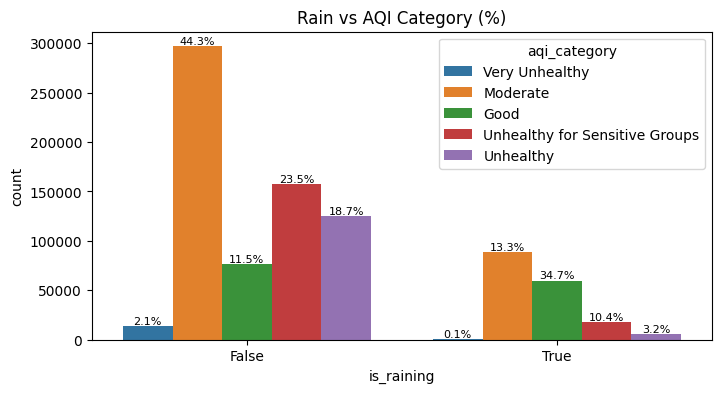

In [26]:
plt.figure(figsize=(8,4))

ax = sns.countplot(x=df['is_raining'].astype(str), hue='aqi_category', data=df)

rain_totals = df['is_raining'].astype(str).value_counts()

for p in ax.patches:
    h = p.get_height()
    if h == 0:
        continue

    rain = ax.get_xticklabels()[int(p.get_x() + p.get_width()/2)].get_text()
    percent = 100 * h / rain_totals[rain]

    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom', fontsize=8)

plt.title('Rain vs AQI Category (%)')
plt.show()


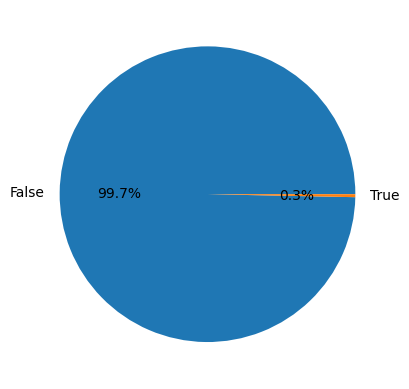

In [27]:
x = df['heavy_rain'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

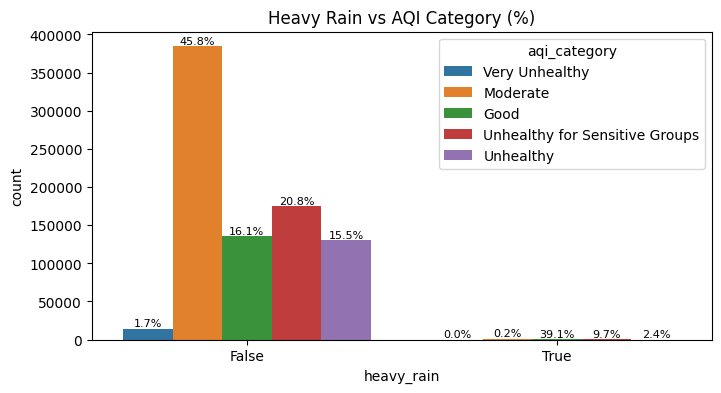

In [28]:
plt.figure(figsize=(8,4))

ax = sns.countplot(x=df['heavy_rain'].astype(str), hue='aqi_category', data=df)

hr_totals = df['heavy_rain'].astype(str).value_counts()

for p in ax.patches:
    h = p.get_height()
    if h == 0:
        continue

    hr = ax.get_xticklabels()[int(p.get_x() + p.get_width()/2)].get_text()
    percent = 100 * h / hr_totals[hr]

    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom', fontsize=8)

plt.title('Heavy Rain vs AQI Category (%)')
plt.show()


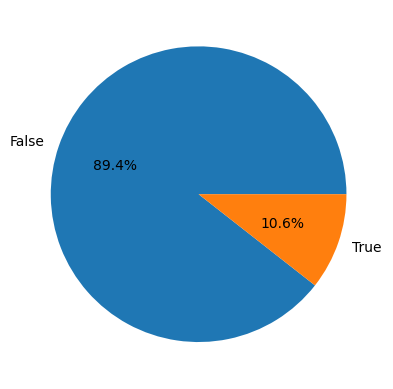

In [29]:
x = df['festival_period'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

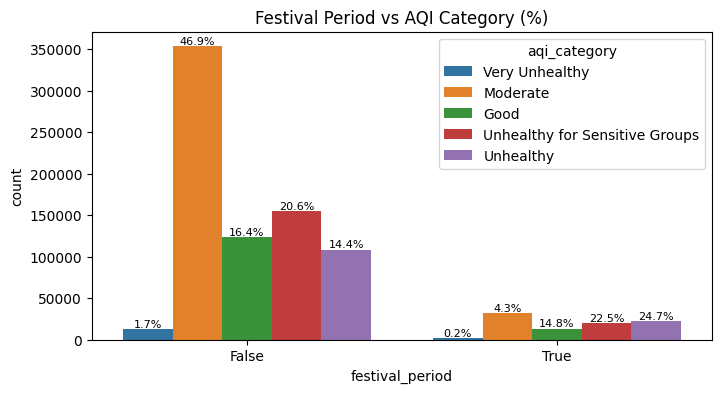

In [30]:
plt.figure(figsize=(8,4))

ax = sns.countplot(x=df['festival_period'].astype(str), hue='aqi_category', data=df)

fp_totals = df['festival_period'].astype(str).value_counts()

for p in ax.patches:
    h = p.get_height()
    if h == 0:
        continue

    fp = ax.get_xticklabels()[int(p.get_x() + p.get_width()/2)].get_text()
    percent = 100 * h / fp_totals[fp]

    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom', fontsize=8)

plt.title('Festival Period vs AQI Category (%)')
plt.show()


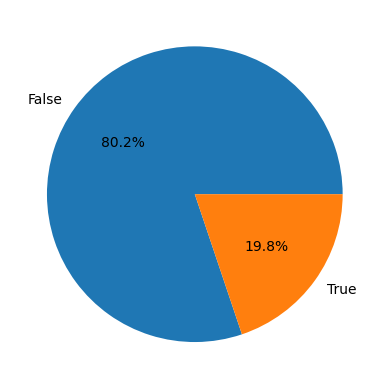

In [31]:
x = df['crop_burning_season'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

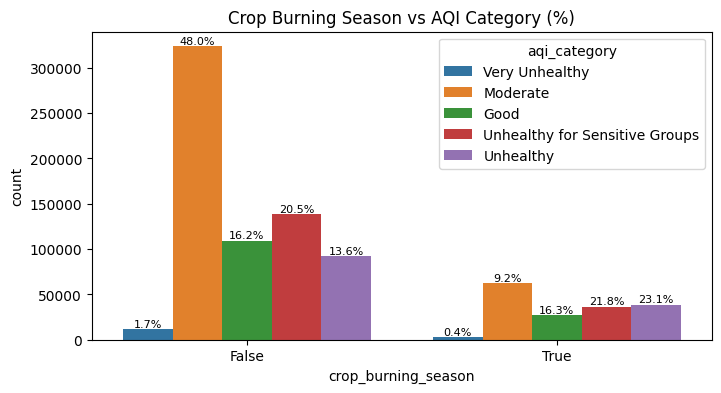

In [32]:
plt.figure(figsize=(8,4))

ax = sns.countplot(x=df['crop_burning_season'].astype(str),
                   hue='aqi_category',
                   data=df)

cb_totals = df['crop_burning_season'].astype(str).value_counts()

for p in ax.patches:
    h = p.get_height()
    if h == 0:
        continue

    cb = ax.get_xticklabels()[int(p.get_x() + p.get_width()/2)].get_text()
    percent = 100 * h / cb_totals[cb]

    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom', fontsize=8)

plt.title('Crop Burning Season vs AQI Category (%)')
plt.show()


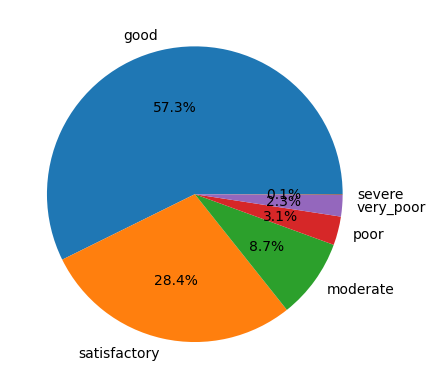

In [33]:
x = df['pm25_category_india'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

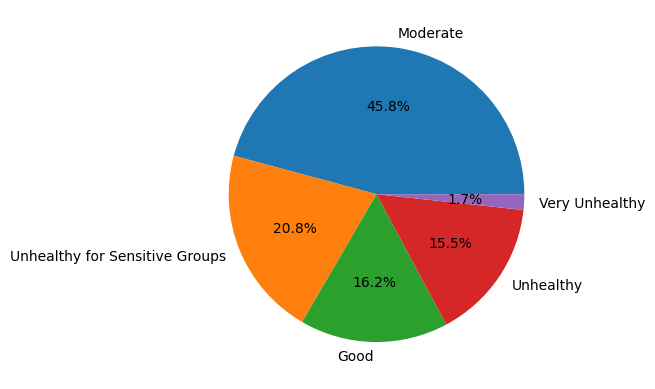

In [34]:
x = df['aqi_category'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

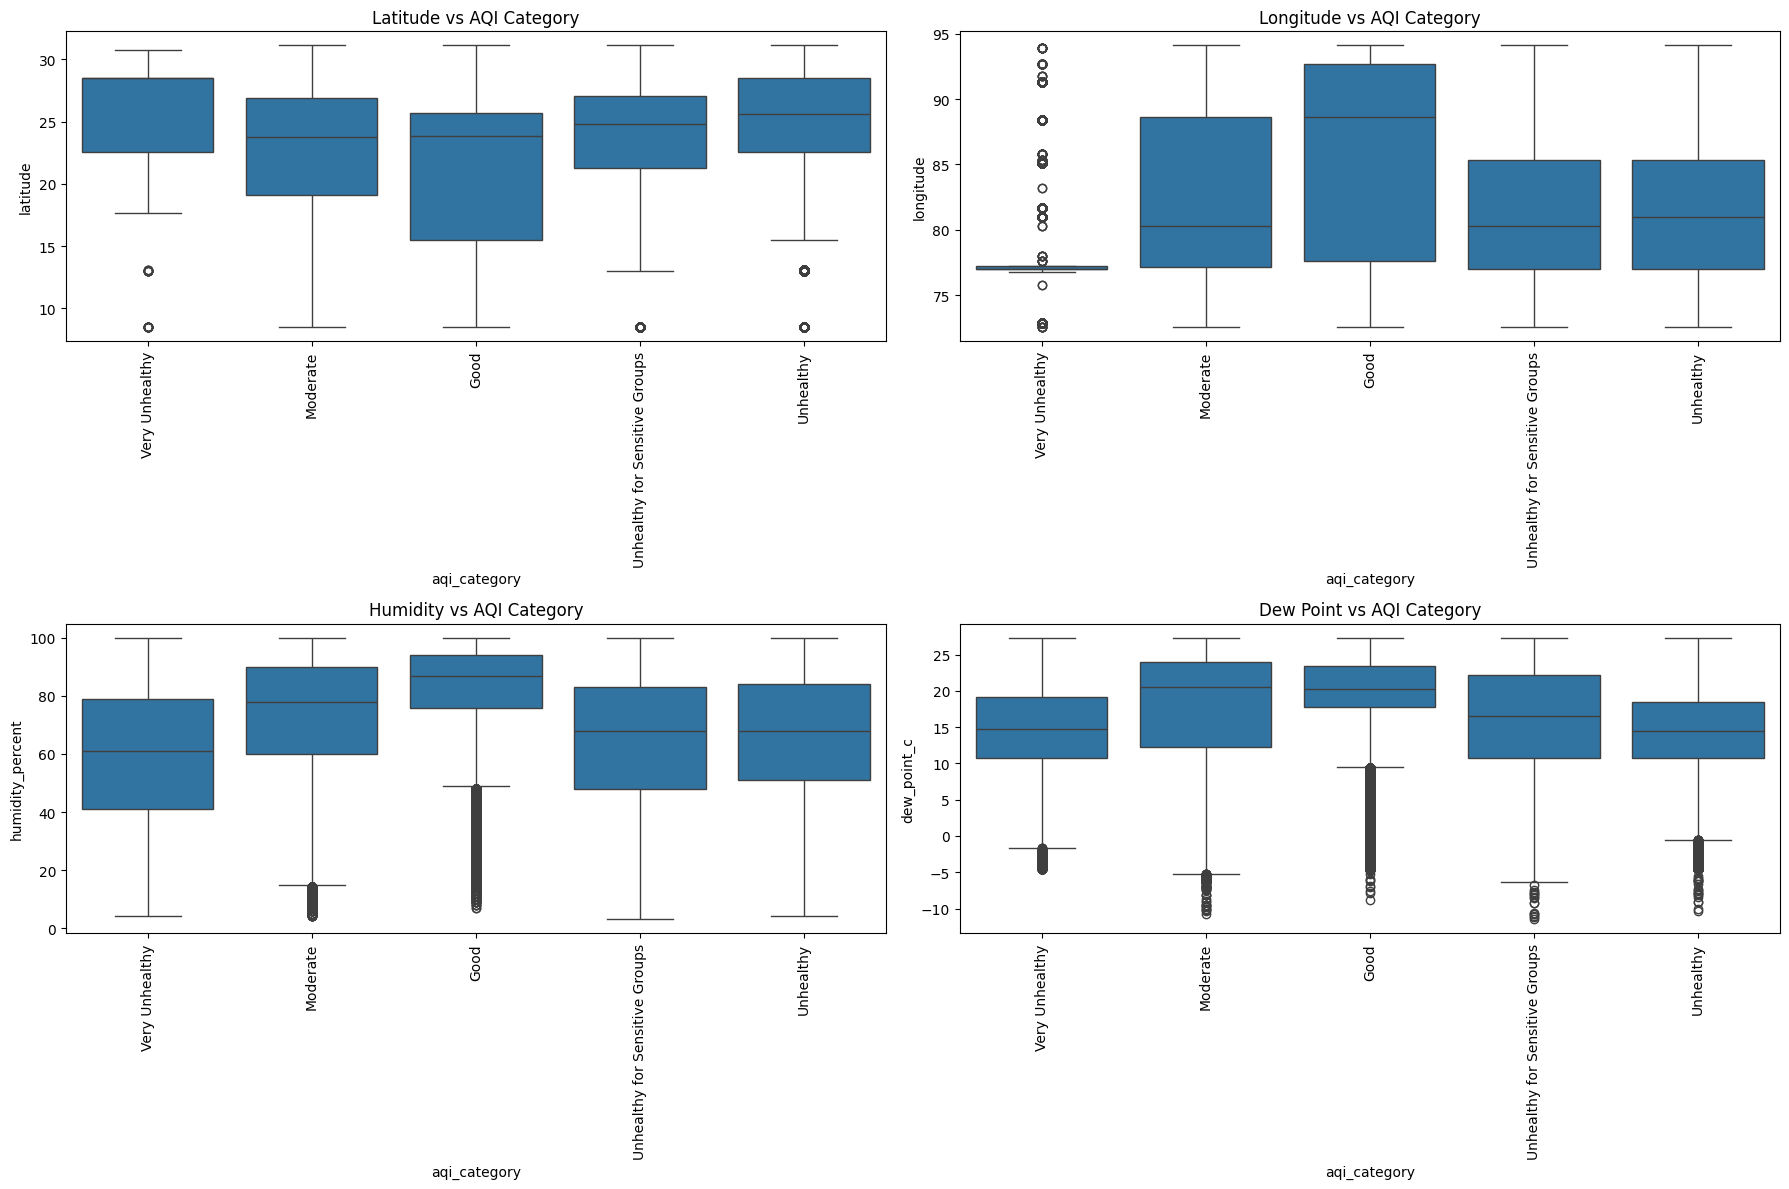

In [35]:

plt.figure(figsize=(18, 12))

# Latitude vs AQI
plt.subplot(2, 2, 1)
sns.boxplot(x='aqi_category', y='latitude', data=df)
plt.xticks(rotation=90)
plt.title('Latitude vs AQI Category')

#  Longitude vs AQI
plt.subplot(2, 2, 2)
sns.boxplot(x='aqi_category', y='longitude', data=df)
plt.xticks(rotation=90)
plt.title('Longitude vs AQI Category')

#  Humidity vs AQI
plt.subplot(2, 2, 3)
sns.boxplot(x='aqi_category', y='humidity_percent', data=df)
plt.xticks(rotation=90)
plt.title('Humidity vs AQI Category')

#  Dew Point vs AQI
plt.subplot(2, 2, 4)
sns.boxplot(x='aqi_category', y='dew_point_c', data=df)
plt.xticks(rotation=90)
plt.title('Dew Point vs AQI Category')

plt.tight_layout()
plt.show()

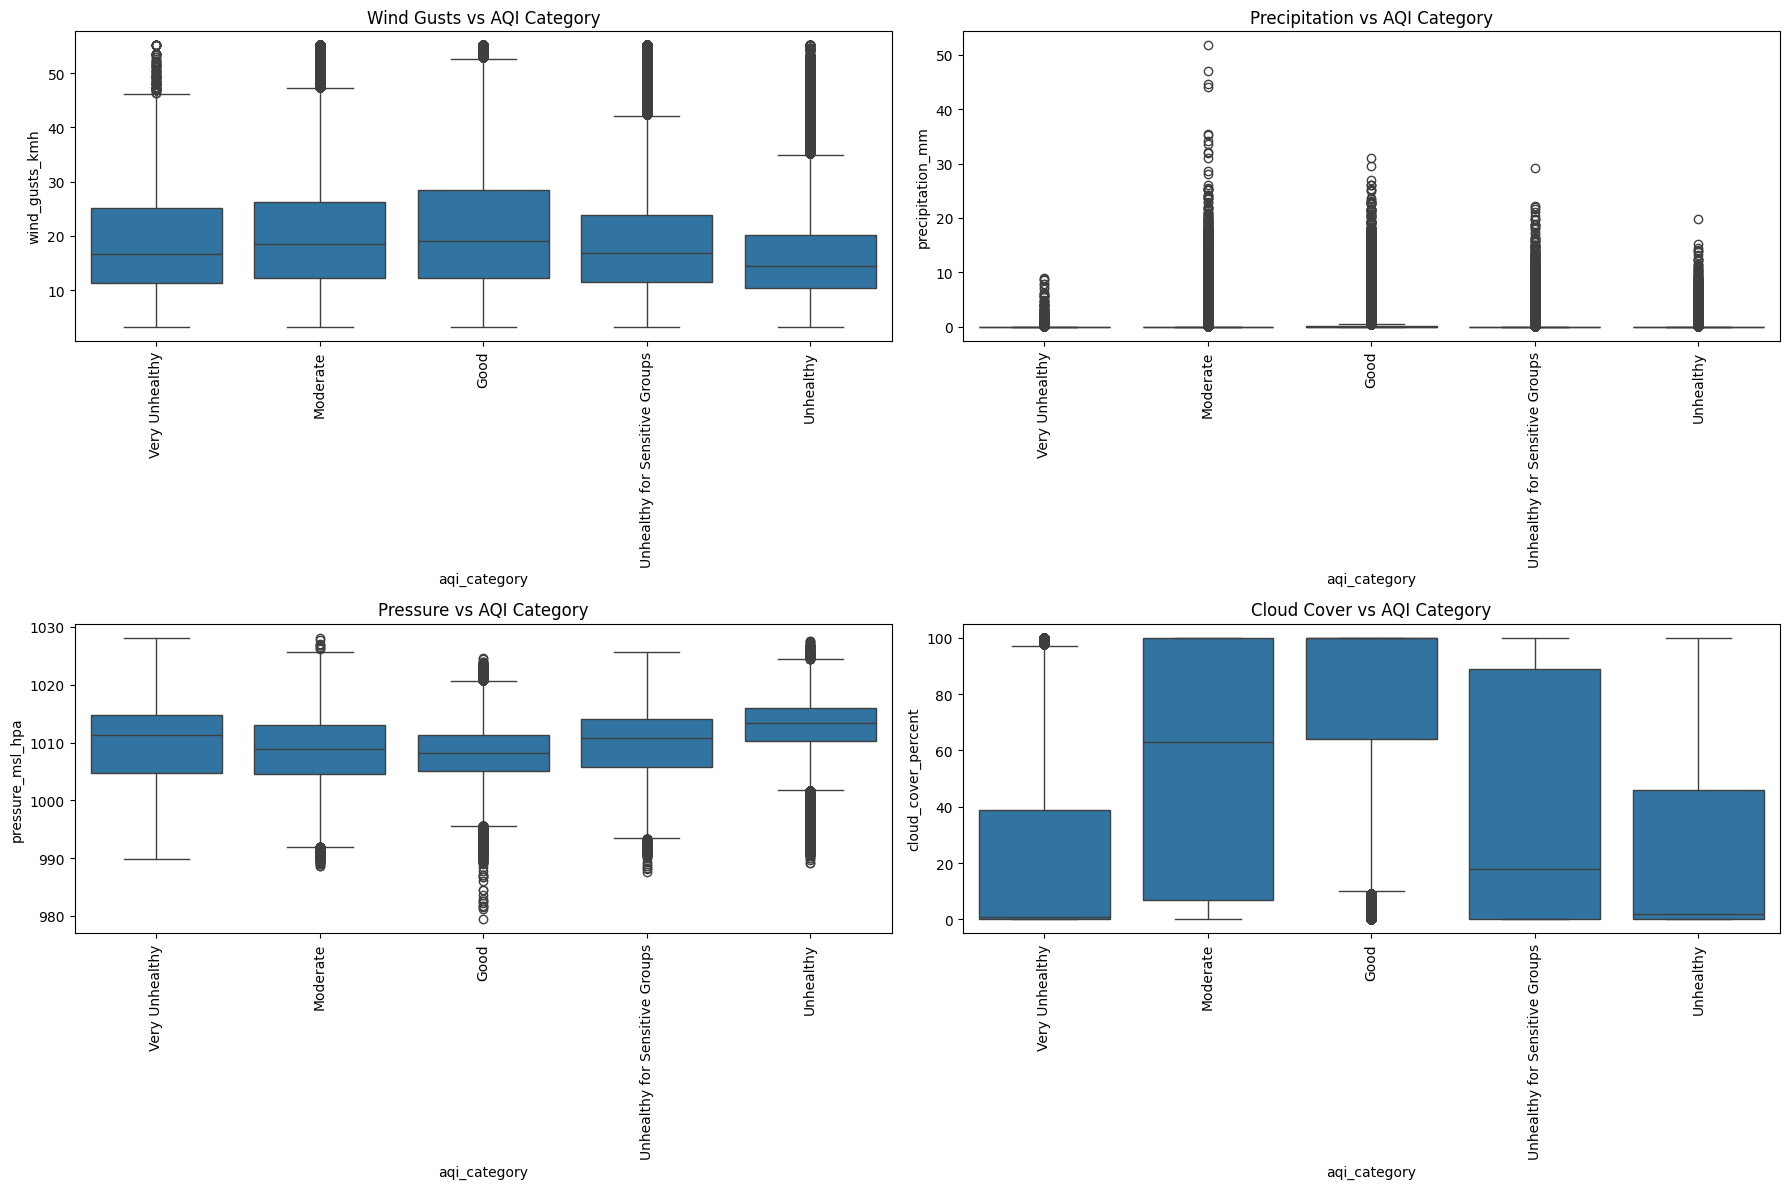

In [36]:
plt.figure(figsize=(18, 12))

#  Wind Gusts vs AQI
plt.subplot(2, 2, 1)
sns.boxplot(x='aqi_category', y='wind_gusts_kmh', data=df)
plt.xticks(rotation=90)
plt.title('Wind Gusts vs AQI Category')

#  Precipitation vs AQI
plt.subplot(2, 2, 2)
sns.boxplot(x='aqi_category', y='precipitation_mm', data=df)
plt.xticks(rotation=90)
plt.title('Precipitation vs AQI Category')

#  Pressure vs AQI
plt.subplot(2, 2, 3)
sns.boxplot(x='aqi_category', y='pressure_msl_hpa', data=df)
plt.xticks(rotation=90)
plt.title('Pressure vs AQI Category')

#  Cloud Cover vs AQI
plt.subplot(2, 2, 4)
sns.boxplot(x='aqi_category', y='cloud_cover_percent', data=df)
plt.xticks(rotation=90)
plt.title('Cloud Cover vs AQI Category')

plt.tight_layout()
plt.show()

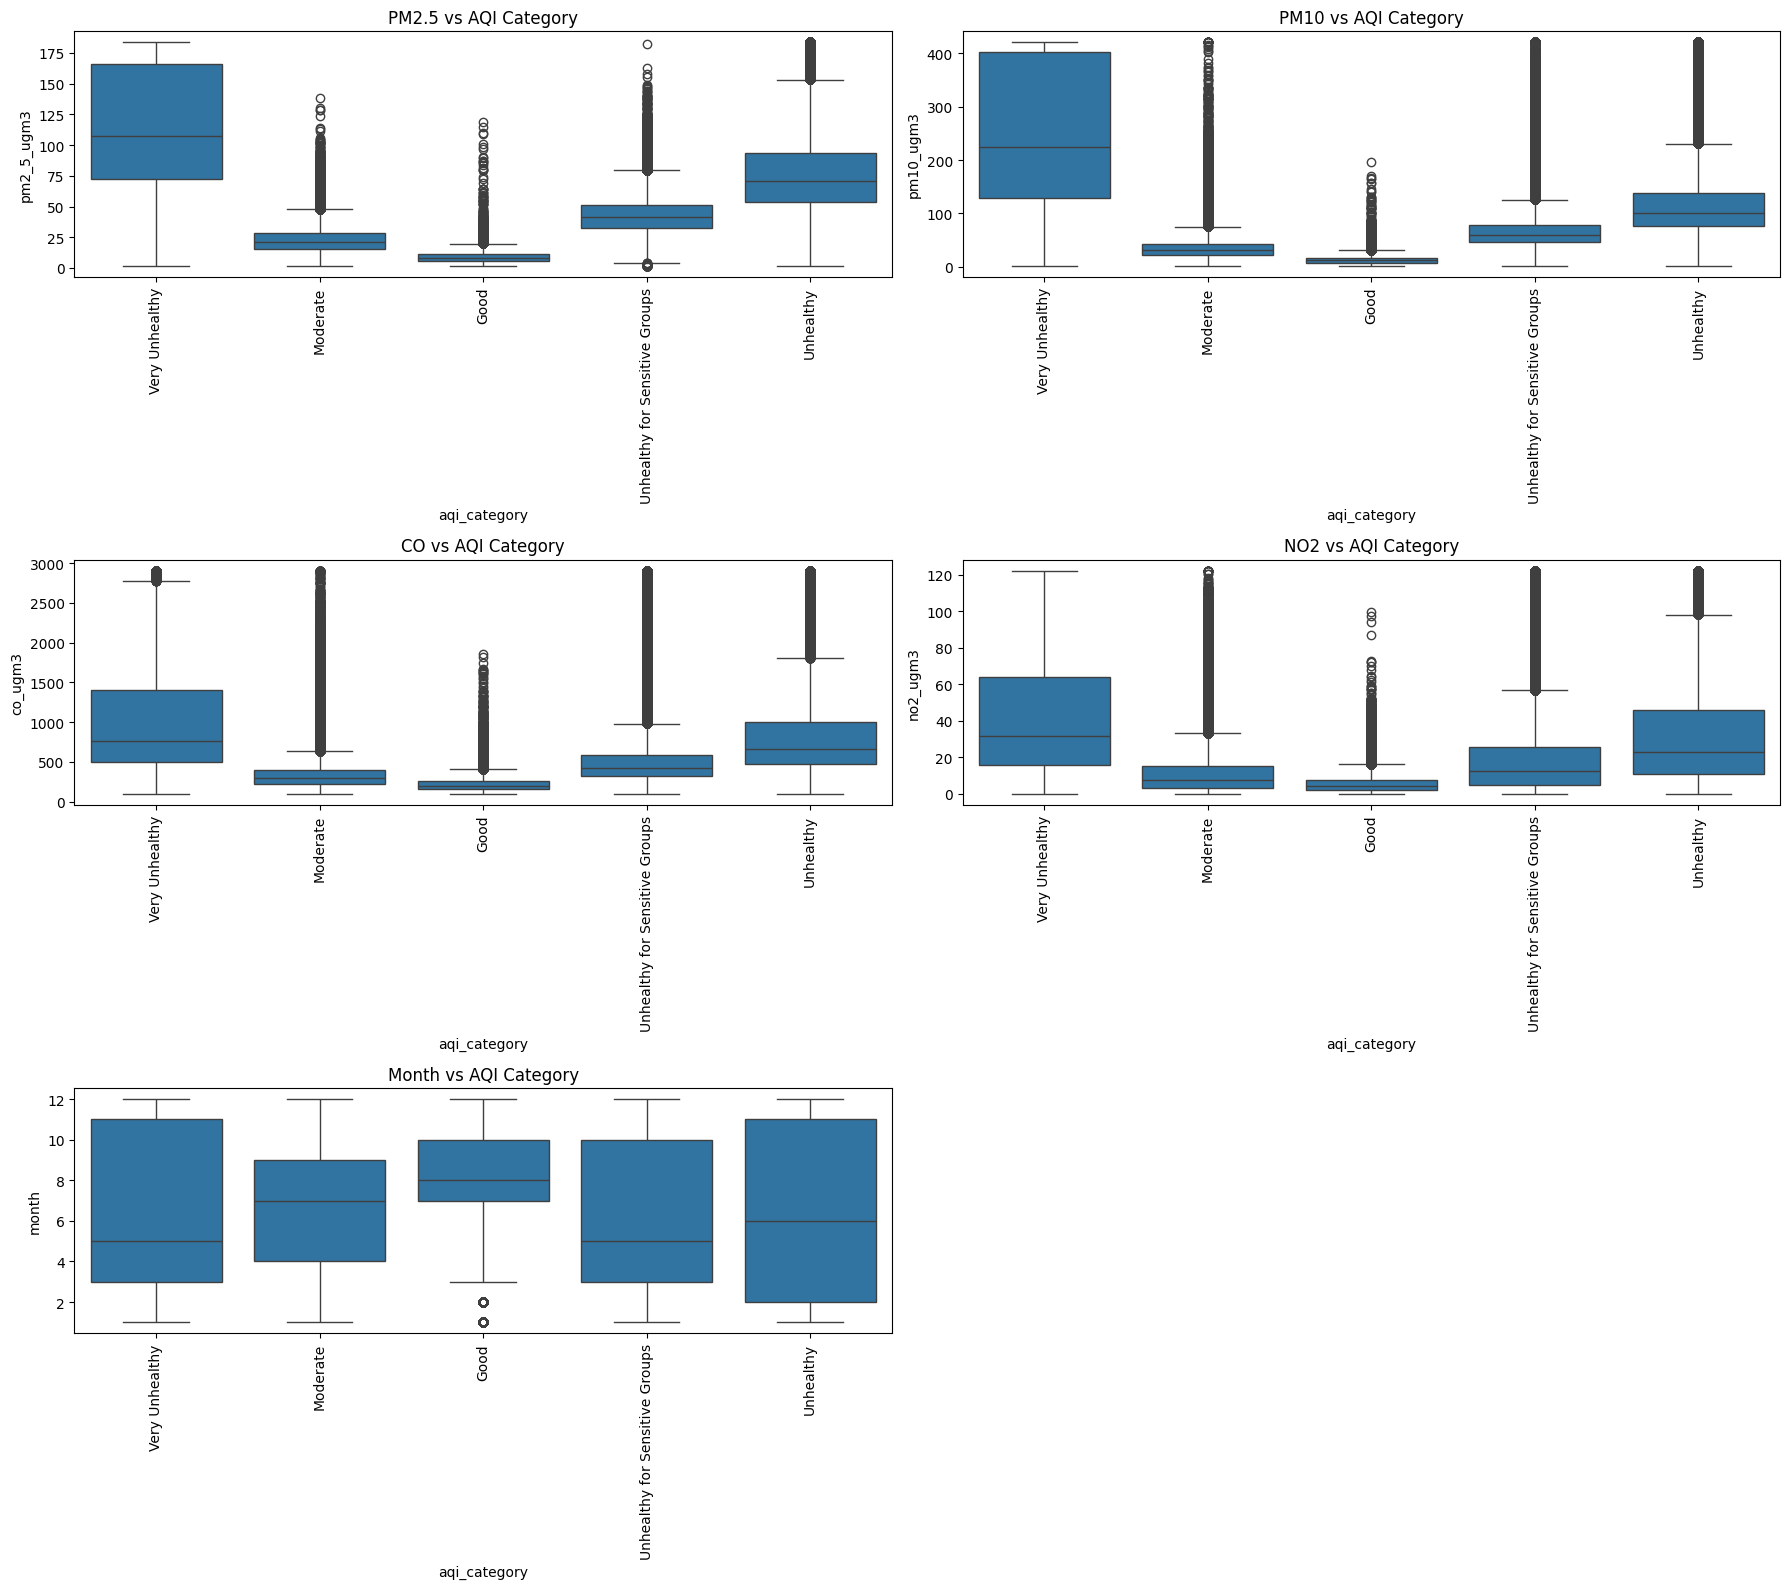

In [37]:
plt.figure(figsize=(18, 16))

#  PM2.5 vs AQI
plt.subplot(3, 2, 1)
sns.boxplot(x='aqi_category', y='pm2_5_ugm3', data=df)
plt.xticks(rotation=90)
plt.title('PM2.5 vs AQI Category')

#  PM10 vs AQI
plt.subplot(3, 2, 2)
sns.boxplot(x='aqi_category', y='pm10_ugm3', data=df)
plt.xticks(rotation=90)
plt.title('PM10 vs AQI Category')

#  CO vs AQI
plt.subplot(3, 2, 3)
sns.boxplot(x='aqi_category', y='co_ugm3', data=df)
plt.xticks(rotation=90)
plt.title('CO vs AQI Category')

#  NO2 vs AQI
plt.subplot(3, 2, 4)
sns.boxplot(x='aqi_category', y='no2_ugm3', data=df)
plt.xticks(rotation=90)
plt.title('NO2 vs AQI Category')

#  Month vs AQI
plt.subplot(3, 2, 5)
sns.boxplot(x='aqi_category', y='month', data=df)
plt.xticks(rotation=90)
plt.title('Month vs AQI Category')

plt.tight_layout()
plt.show()

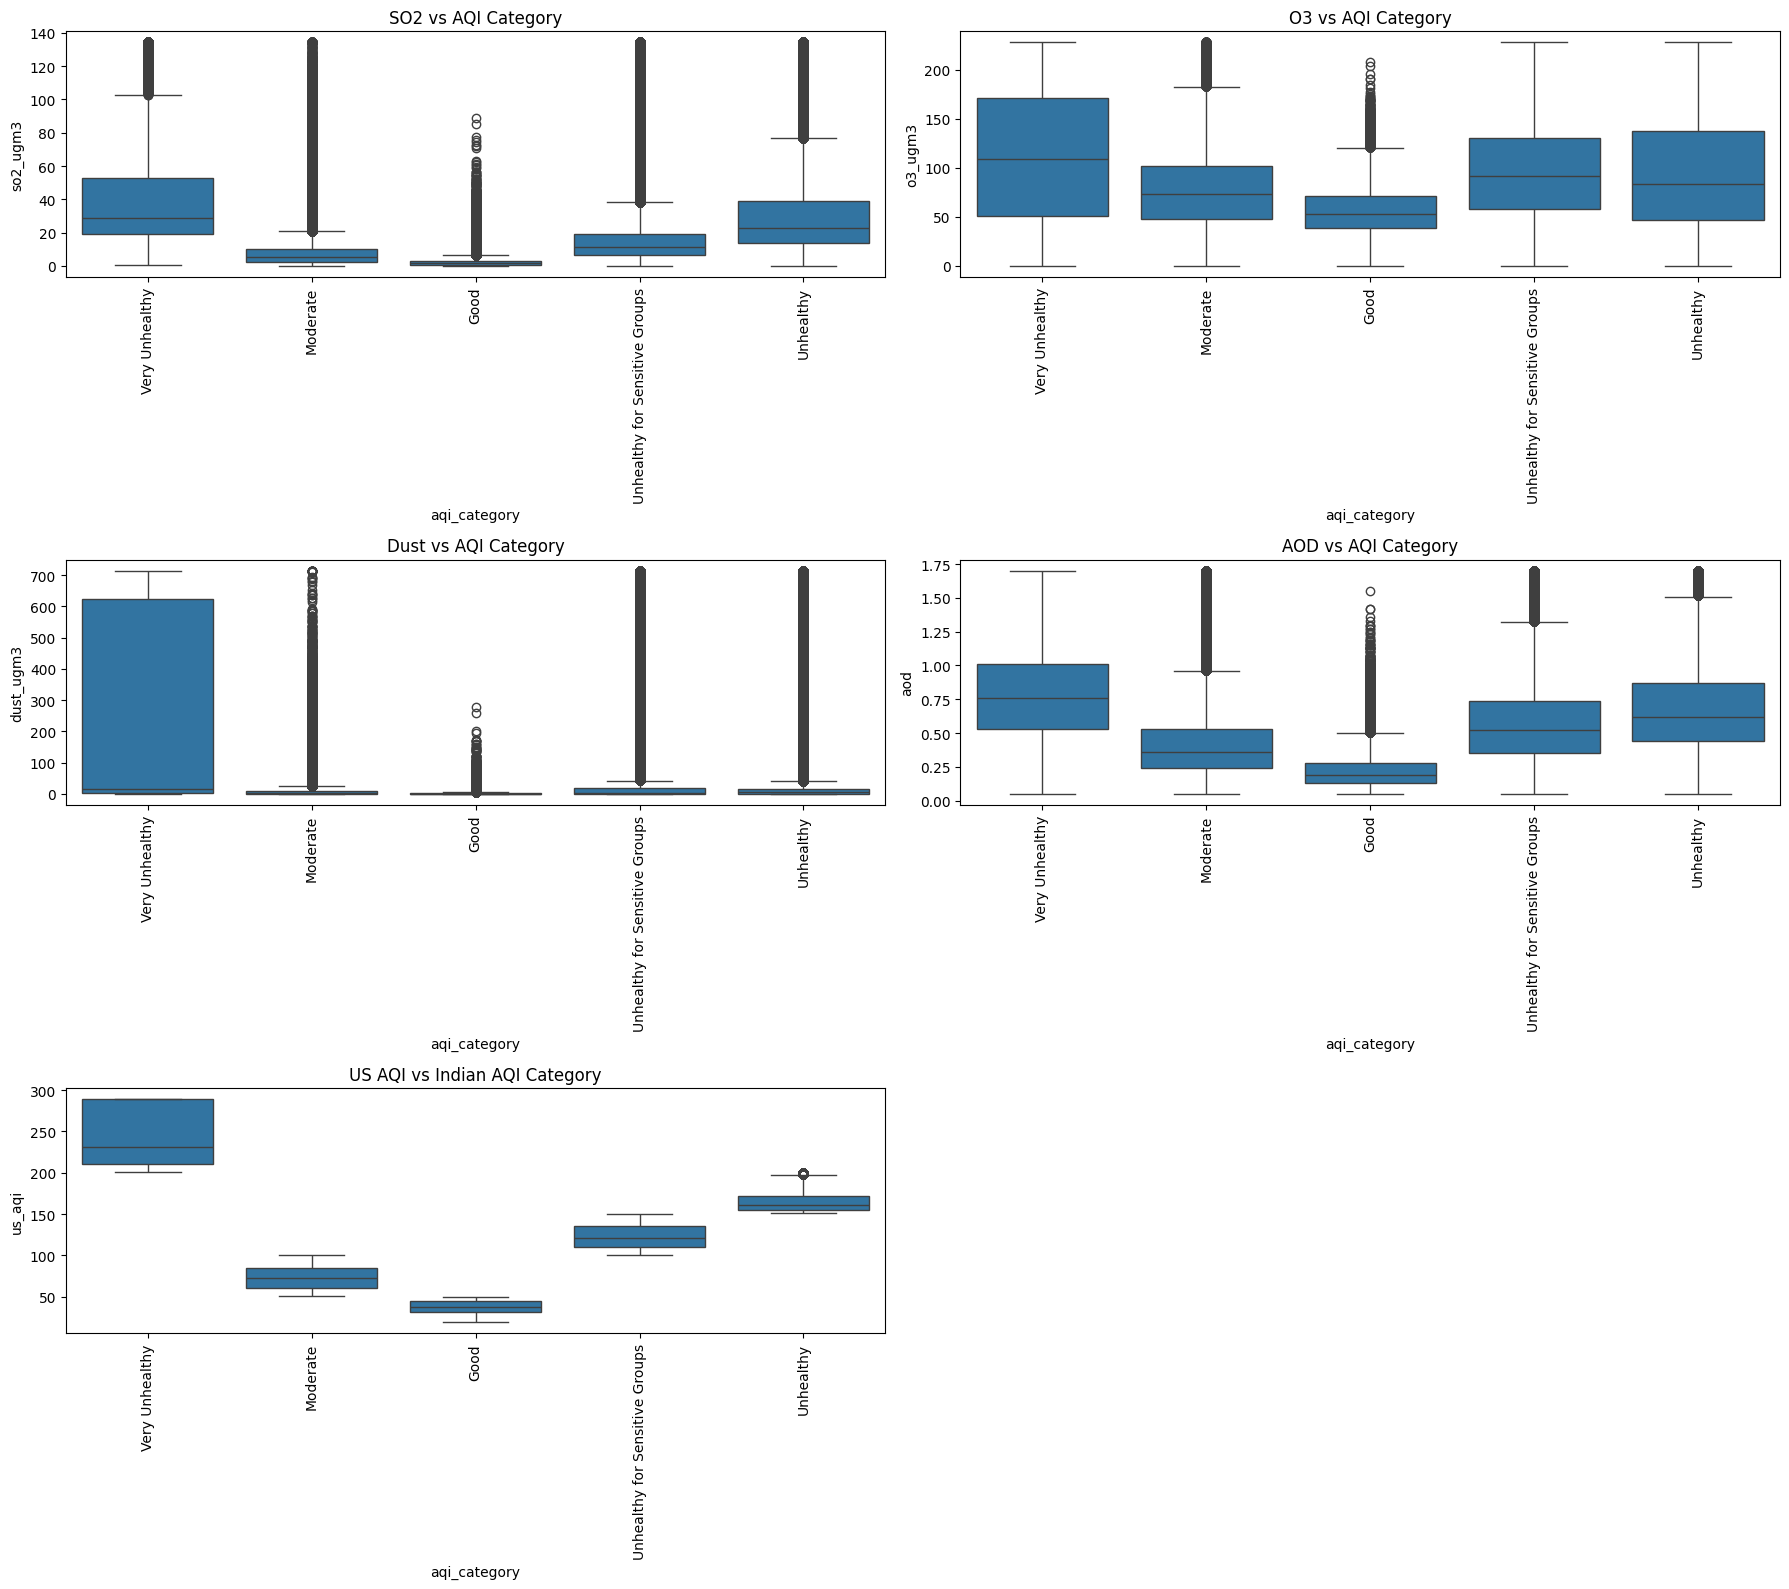

In [38]:
plt.figure(figsize=(18, 16))

#  SO2 vs AQI
plt.subplot(3, 2, 1)
sns.boxplot(x='aqi_category', y='so2_ugm3', data=df)
plt.xticks(rotation=90)
plt.title('SO2 vs AQI Category')

#  O3 vs AQI
plt.subplot(3, 2, 2)
sns.boxplot(x='aqi_category', y='o3_ugm3', data=df)
plt.xticks(rotation=90)
plt.title('O3 vs AQI Category')

#  Dust vs AQI
plt.subplot(3, 2, 3)
sns.boxplot(x='aqi_category', y='dust_ugm3', data=df)
plt.xticks(rotation=90)
plt.title('Dust vs AQI Category')

#  AOD vs AQI
plt.subplot(3, 2, 4)
sns.boxplot(x='aqi_category', y='aod', data=df)
plt.xticks(rotation=90)
plt.title('AOD vs AQI Category')

#  US AQI vs Indian AQI Category
plt.subplot(3, 2, 5)
sns.boxplot(x='aqi_category', y='us_aqi', data=df)
plt.xticks(rotation=90)
plt.title('US AQI vs Indian AQI Category')

plt.tight_layout()
plt.show()

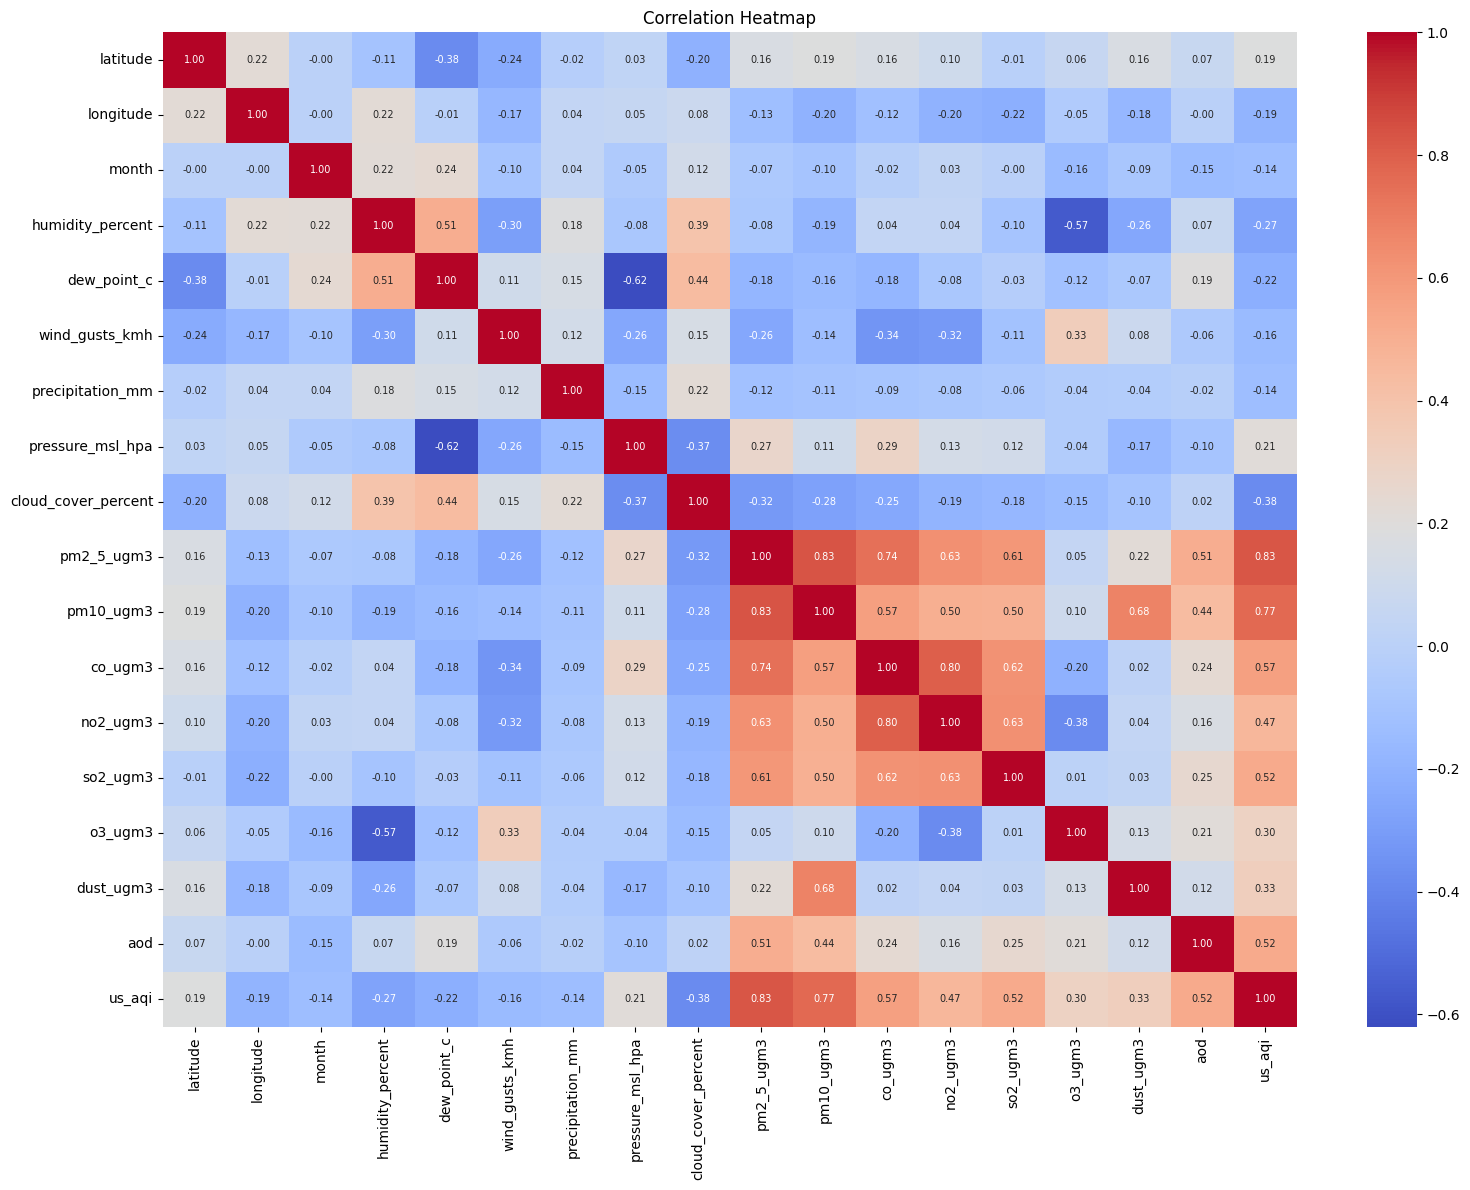

In [39]:

plt.figure(figsize=(16,12))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            fmt='.2f',
            annot_kws={'size': 7},
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [40]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3',
        'humidity_percent', 'dew_point_c', 'wind_gusts_kmh',
        'precipitation_mm', 'pressure_msl_hpa',
        'cloud_cover_percent', 'dust_ugm3', 'aod',
        'latitude', 'longitude', 'month', 'o3_ugm3']]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

                Feature         VIF
0            pm2_5_ugm3   32.513726
1             pm10_ugm3   49.675783
2               co_ugm3   10.369673
3              no2_ugm3    7.257710
4              so2_ugm3    3.331059
5      humidity_percent   37.448638
6           dew_point_c   15.845054
7        wind_gusts_kmh    7.154323
8      precipitation_mm    1.147198
9      pressure_msl_hpa  226.239289
10  cloud_cover_percent    3.542325
11            dust_ugm3    9.130529
12                  aod    6.382539
13             latitude   26.340130
14            longitude  181.788962
15                month    5.793077
16              o3_ugm3   11.008624


In [41]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3',
        'humidity_percent', 'dew_point_c', 'wind_gusts_kmh',
        'precipitation_mm',
        'cloud_cover_percent', 'dust_ugm3', 'aod',
        'latitude', 'longitude', 'month', 'o3_ugm3']]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

                Feature        VIF
0            pm2_5_ugm3  32.501544
1             pm10_ugm3  49.670624
2               co_ugm3  10.367242
3              no2_ugm3   6.886364
4              so2_ugm3   3.328154
5      humidity_percent  35.095753
6           dew_point_c  15.841206
7        wind_gusts_kmh   6.205601
8      precipitation_mm   1.137049
9   cloud_cover_percent   3.532573
10            dust_ugm3   9.112284
11                  aod   6.353700
12             latitude  26.026196
13            longitude  65.269763
14                month   5.705278
15              o3_ugm3  10.165756


In [42]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3',
        'humidity_percent', 'dew_point_c', 'wind_gusts_kmh',
        'precipitation_mm',
        'cloud_cover_percent', 'dust_ugm3', 'aod',
        'month', 'o3_ugm3']]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

                Feature        VIF
0            pm2_5_ugm3  32.500904
1             pm10_ugm3  49.385117
2               co_ugm3  10.303300
3              no2_ugm3   6.354527
4              so2_ugm3   3.262624
5      humidity_percent  15.498967
6           dew_point_c  13.561340
7        wind_gusts_kmh   5.480761
8      precipitation_mm   1.119428
9   cloud_cover_percent   3.512608
10            dust_ugm3   8.860188
11                  aod   6.243320
12                month   5.395717
13              o3_ugm3   6.063415


In [43]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['pm2_5_ugm3',  'co_ugm3', 'no2_ugm3', 'so2_ugm3',
        'humidity_percent', 'dew_point_c', 'wind_gusts_kmh',
        'precipitation_mm',
        'cloud_cover_percent', 'dust_ugm3', 'aod',
        'month', 'o3_ugm3']]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

                Feature        VIF
0            pm2_5_ugm3   9.572657
1               co_ugm3  10.118520
2              no2_ugm3   6.354259
3              so2_ugm3   3.150192
4      humidity_percent  15.480479
5           dew_point_c  13.556487
6        wind_gusts_kmh   5.480256
7      precipitation_mm   1.119417
8   cloud_cover_percent   3.509073
9             dust_ugm3   1.252231
10                  aod   6.162821
11                month   5.395179
12              o3_ugm3   6.061686


In [44]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['pm2_5_ugm3',  'co_ugm3', 'no2_ugm3', 'so2_ugm3'
        , 'dew_point_c', 'wind_gusts_kmh',
        'precipitation_mm',
        'cloud_cover_percent', 'dust_ugm3', 'aod',
        'month', 'o3_ugm3']]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

                Feature       VIF
0            pm2_5_ugm3  9.446038
1               co_ugm3  9.223599
2              no2_ugm3  6.305826
3              so2_ugm3  2.968483
4           dew_point_c  9.176461
5        wind_gusts_kmh  5.433900
6      precipitation_mm  1.114489
7   cloud_cover_percent  3.314253
8             dust_ugm3  1.221491
9                   aod  6.119473
10                month  4.808473
11              o3_ugm3  5.958177


In [45]:
df.columns

Index(['city', 'state', 'latitude', 'longitude', 'datetime', 'month',
       'day_name', 'is_weekend', 'season', 'time_of_day', 'humidity_percent',
       'dew_point_c', 'wind_gusts_kmh', 'precipitation_mm', 'is_raining',
       'heavy_rain', 'pressure_msl_hpa', 'cloud_cover_percent', 'pm2_5_ugm3',
       'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'dust_ugm3',
       'aod', 'us_aqi', 'aqi_category', 'pm25_category_india',
       'festival_period', 'crop_burning_season'],
      dtype='object')

Based on the VIF analysis above, the following columns are removed:

pressure_msl_hpa → VIF 226 (extremely high multicollinearity)

humidity_percent → VIF 35 (collinear with dew_point_c)

pm10_ugm3 → VIF 49 (collinear with pm2_5_ugm3)

latitude, longitude → geographic identifiers, not useful for prediction

city, datetime → identifier columns

us_aqi, pm25_category_india → data leakage (directly reveal the target variable)

month, day_name → redundant since season and time_of_day already encode similar information

wind_gusts_kmh, precipitation_mm, is_raining, dust_ugm3 → low predictive value

In [46]:

df = df.drop([
    'city', 'datetime', 'latitude', 'longitude',
    'pressure_msl_hpa',
    'humidity_percent',
    'month',
    'day_name',
    'wind_gusts_kmh',
    'precipitation_mm',
    'is_raining',
    'pm10_ugm3',
    'dust_ugm3',
    'us_aqi',
    'pm25_category_india'
], axis='columns')
df.shape

(842158, 16)

In [47]:
df.columns

Index(['state', 'is_weekend', 'season', 'time_of_day', 'dew_point_c',
       'heavy_rain', 'cloud_cover_percent', 'pm2_5_ugm3', 'co_ugm3',
       'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'aod', 'aqi_category',
       'festival_period', 'crop_burning_season'],
      dtype='object')

In [48]:
df_before = df.copy()

outlier_cols = [
    'dew_point_c',
    'cloud_cover_percent',
    'pm2_5_ugm3',
    'co_ugm3',
    'no2_ugm3',
    'so2_ugm3',
    'o3_ugm3',
    'aod'
]

report = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    n_capped = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)

    report.append({
        'Column': col,
        'Lower Cap': round(lower, 2),
        'Upper Cap': round(upper, 2),
        'Rows Capped': n_capped,
        'Pct Capped': round(n_capped / len(df) * 100, 3)
    })

import pandas as pd
print(pd.DataFrame(report).to_string(index=False))

             Column  Lower Cap  Upper Cap  Rows Capped  Pct Capped
        dew_point_c     -21.50      56.90            0       0.000
cloud_cover_percent    -292.00     394.00            0       0.000
         pm2_5_ugm3     -73.80     132.70        14527       1.725
            co_ugm3    -584.00    1327.00        28475       3.381
           no2_ugm3     -44.90      68.50        28551       3.390
           so2_ugm3     -36.20      54.80        32928       3.910
            o3_ugm3    -136.00     291.00            0       0.000
                aod      -0.87       1.72            0       0.000


In [49]:
bool_cols = ['is_weekend', 'heavy_rain',
             'festival_period', 'crop_burning_season']

df[bool_cols] = df[bool_cols].astype(int)

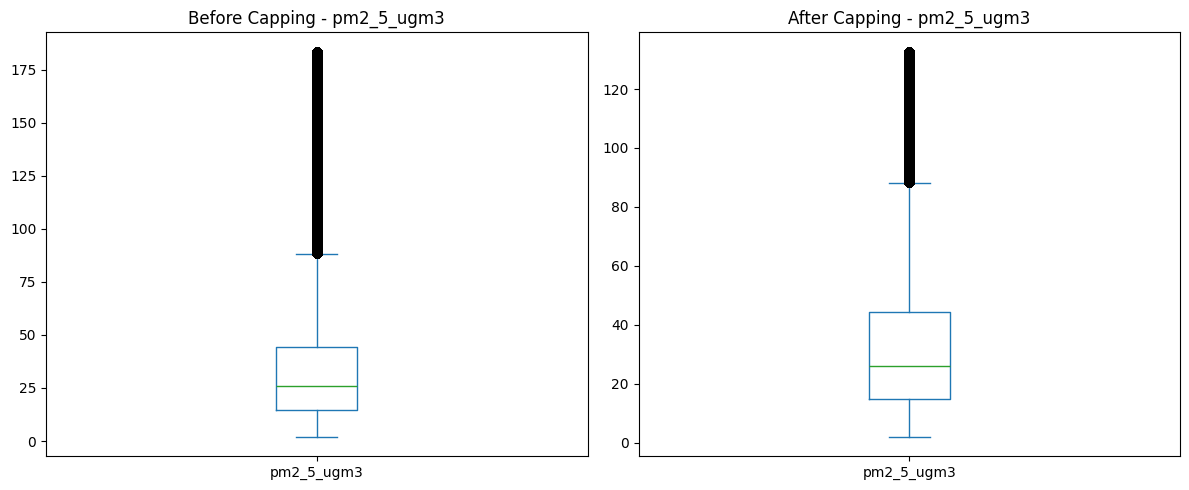

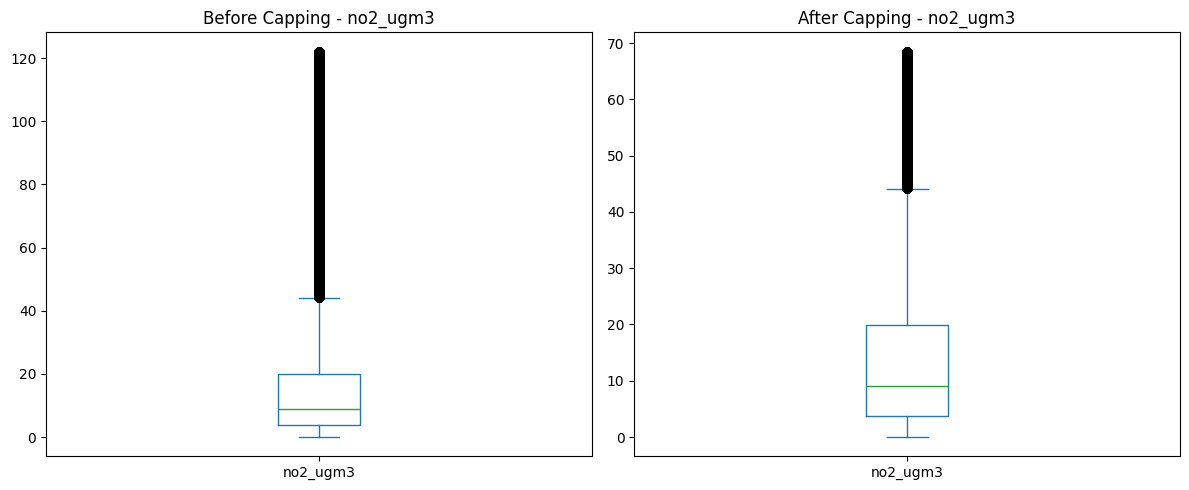

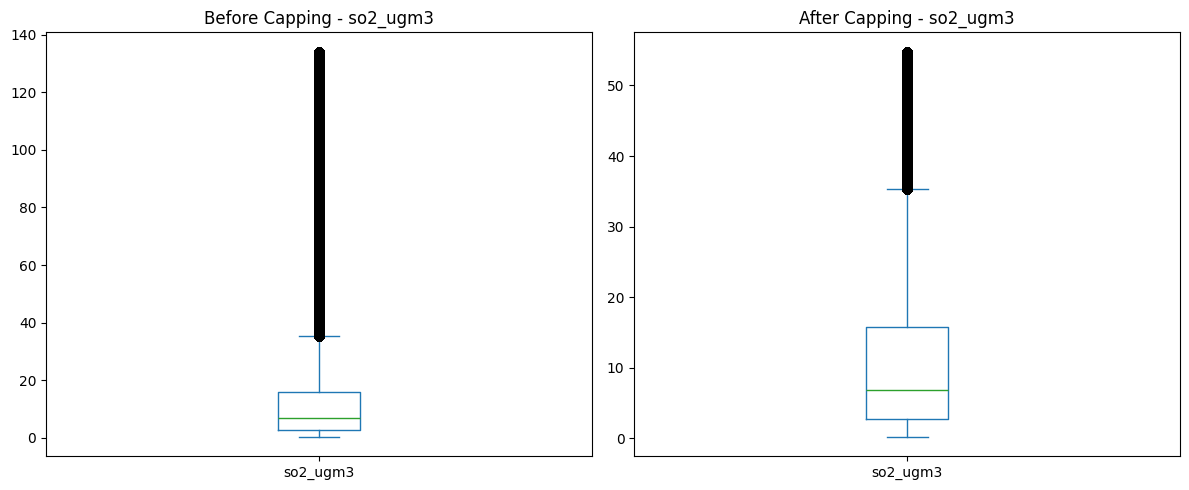

In [50]:
import matplotlib.pyplot as plt

cols = ['pm2_5_ugm3', 'no2_ugm3', 'so2_ugm3']

for col in cols:

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))


    df_before[col].plot(kind='box', ax=axes[0])
    axes[0].set_title(f'Before Capping - {col}')

    df[col].plot(kind='box', ax=axes[1])
    axes[1].set_title(f'After Capping - {col}')

    plt.tight_layout()
    plt.show()

In [51]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

cols = ['season', 'time_of_day', 'state']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded = encoder.fit_transform(df[cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cols),
    index=df.index
)

df = pd.concat([df.drop(cols, axis=1), encoded_df], axis=1)
print(df.head())

   is_weekend  dew_point_c  heavy_rain  cloud_cover_percent  pm2_5_ugm3  \
0           0         25.1           0                100.0        14.8   
1           0         25.2           0                100.0        15.7   
2           0         25.2           0                100.0        16.3   
3           0         25.2           0                100.0        17.6   
4           0         25.2           0                100.0        18.2   

   co_ugm3  no2_ugm3  so2_ugm3  o3_ugm3   aod  ... state_odisha  state_punjab  \
0    197.0      21.8       2.7     32.0  0.14  ...          0.0           0.0   
1    196.0      18.5       3.0     33.0  0.14  ...          0.0           0.0   
2    196.0      15.1       3.3     34.0  0.15  ...          0.0           0.0   
3    197.0      14.1       3.3     32.0  0.15  ...          0.0           0.0   
4    199.0      13.9       3.2     30.0  0.14  ...          0.0           0.0   

   state_rajasthan  state_sikkim  state_tamil nadu  state_tela

In [52]:
df.columns = df.columns.str.replace(" ", "_")

In [53]:

severity_order = {
    'Good': 0,
    'Moderate': 1,
    'Unhealthy for Sensitive Groups': 2,
    'Unhealthy': 3,
    'Very Unhealthy': 4
}

df['aqi_category'] = df['aqi_category'].map(severity_order)

print('AQI Category Encoding:')
for name, code in severity_order.items():
    print(f'  {code} = {name}')

AQI Category Encoding:
  0 = Good
  1 = Moderate
  2 = Unhealthy for Sensitive Groups
  3 = Unhealthy
  4 = Very Unhealthy


In [54]:
X = df.drop('aqi_category', axis=1)
y = df['aqi_category']

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [57]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [58]:
y_pred_lr = lr.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7096691840030398
              precision    recall  f1-score   support

           0       0.69      0.90      0.78     27295
           1       0.86      0.69      0.77     77167
           2       0.57      0.67      0.62     35025
           3       0.74      0.60      0.66     26072
           4       0.29      0.87      0.44      2873

    accuracy                           0.71    168432
   macro avg       0.63      0.75      0.65    168432
weighted avg       0.74      0.71      0.72    168432



In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [61]:
y_pred_rf = rf.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8529970551914126

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.85      0.87     27295
           1       0.87      0.91      0.89     77167
           2       0.78      0.75      0.76     35025
           3       0.86      0.83      0.85     26072
           4       0.88      0.63      0.73      2873

    accuracy                           0.85    168432
   macro avg       0.86      0.80      0.82    168432
weighted avg       0.85      0.85      0.85    168432



In [63]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [64]:
y_pred_xgb = xgb.predict(X_test)

In [65]:
from sklearn.metrics import accuracy_score, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7354956302840315

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.90      0.80     27295
           1       0.87      0.71      0.78     77167
           2       0.59      0.70      0.64     35025
           3       0.77      0.66      0.71     26072
           4       0.37      0.91      0.53      2873

    accuracy                           0.74    168432
   macro avg       0.66      0.78      0.69    168432
weighted avg       0.76      0.74      0.74    168432



In [66]:
import pandas as pd
from sklearn.metrics import f1_score

results = pd.DataFrame({

    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted')
    ]

})

print("\nMODEL COMPARISON\n")

print(results.sort_values(by='Accuracy', ascending=False))


MODEL COMPARISON

                 Model  Accuracy  F1 Score
1        Random Forest  0.852997  0.852006
2              XGBoost  0.735496  0.740463
0  Logistic Regression  0.709669  0.715983


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest Accuracy: 0.8526467654602451


In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[23196  4082     9     8     0]
 [ 2731 70607  3708   121     0]
 [    8  6353 26361  2285    18]
 [    6   323  3798 21710   235]
 [    3     8    80   984  1798]]


In [68]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X_train.columns)

importance = importance.sort_values(ascending=False)

print("\nTop 10 Important Features:\n")
print(importance.head(10))


Top 10 Important Features:

pm2_5_ugm3             0.238893
so2_ugm3               0.110092
aod                    0.096387
co_ugm3                0.087116
o3_ugm3                0.083619
dew_point_c            0.067611
no2_ugm3               0.062895
cloud_cover_percent    0.039411
state_haryana          0.027438
state_maharashtra      0.015381
dtype: float64


In [69]:
import joblib

joblib.dump(rf, 'rf_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

joblib.dump(encoder, 'encoder.pkl')

# y mapping (for reverse lookup)
import json
severity_order = {
    'Good': 0,
    'Moderate': 1,
    'Unhealthy for Sensitive Groups': 2,
    'Unhealthy': 3,
    'Very Unhealthy': 4
}

reverse_mapping = {v: k for k, v in severity_order.items()}

with open('aqi_encoding.json', 'w') as f:
    json.dump(reverse_mapping, f)

print("Saved: rf_model.pkl, scaler.pkl, encoder.pkl, aqi_encoding.json")

Saved: rf_model.pkl, scaler.pkl, encoder.pkl, aqi_encoding.json


In [ ]:
from google.colab import files

files.download('rf_model.pkl')
files.download('scaler.pkl')
files.download('encoder.pkl')
files.download('aqi_encoding.json')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

shutil.copy('rf_model.pkl', '/content/drive/MyDrive/rf_model.pkl')
shutil.copy('scaler.pkl', '/content/drive/MyDrive/scaler.pkl')
shutil.copy('encoder.pkl', '/content/drive/MyDrive/encoder.pkl')
shutil.copy('aqi_encoding.json', '/content/drive/MyDrive/aqi_encoding.json')

print("All files copied to Google Drive!")